# Preparing the BRFSS Data

## Loading


https://www.cdc.gov/brfss/annual_data/annual_2021.html

Codebook: https://www.cdc.gov/brfss/annual_data/2021/pdf/codebook21_llcp-v2-508.pdf

In [1]:
import pandas as pd
import numpy as np

from empiricaldist import Pmf, Cdf

Read the data

In [2]:
data_file = 'LLCP2021.ASC.gz'
url = 'https://www.cdc.gov/brfss/annual_data/2021/llcp_varlayout_21_onecolumn.html'

In [3]:
tables = pd.read_html(url)
column_info = tables[0]
column_info.index = column_info['Variable Name']

In [4]:
column_info['Starting Column'] -= 1
column_info['Ending Column'] = (column_info['Starting Column'] + 
                                column_info['Field Length'])
column_info.head()

,Starting Column,Variable Name,Field Length,Ending Column
Variable Name,,,,
_STATE,0,_STATE,2,2
FMONTH,16,FMONTH,2,18
IDATE,18,IDATE,8,26
IMONTH,18,IMONTH,2,20
IDAY,20,IDAY,2,22


In [5]:
names = ['SEQNO', 'HTM4', 'WTKG3', '_SEX', '_AGEG5YR', 
         '_SMOKER3', '_VEGESU1', '_INCOMG', '_EDUCAG', '_LLCPWT']

names = ['SEQNO', 'HTM4', 'WTKG3', '_SEX', '_AGEG5YR',
         '_VEGESU1', '_INCOMG1', '_LLCPWT']

In [6]:
cols = ['Starting Column', 'Ending Column']
colspecs_df = column_info.loc[names, cols]
colspecs_df

,Starting Column,Ending Column
Variable Name,,
SEQNO,35,45
HTM4,1991,1994
WTKG3,1994,1999
_SEX,1981,1982
_AGEG5YR,1982,1984
_VEGESU1,2059,2065
_INCOMG1,2007,2008
_LLCPWT,1750,1760


In [7]:
colspecs = list(colspecs_df.itertuples(index=False, name=None))
colspecs

[(35, 45),
 (1991, 1994),
 (1994, 1999),
 (1981, 1982),
 (1982, 1984),
 (2059, 2065),
 (2007, 2008),
 (1750, 1760)]

In [8]:
import gzip

fp = gzip.open(data_file)

%time brfss = pd.read_fwf(fp, names=names, colspecs=colspecs)

CPU times: user 7.63 s, sys: 115 ms, total: 7.75 s
Wall time: 7.75 s


In [9]:
brfss.shape

(438693, 8)

In [10]:
brfss.head()

,SEQNO,HTM4,WTKG3,_SEX,_AGEG5YR,_VEGESU1,_INCOMG1,_LLCPWT
0,2021000001,150.0,3266.0,2,11,214.0,3,744.745531
1,2021000002,168.0,NaN,2,10,128.0,9,299.137394
2,2021000003,165.0,7711.0,2,11,71.0,2,587.862986
3,2021000004,163.0,8845.0,2,9,165.0,5,1099.621570
4,2021000005,180.0,9344.0,1,12,258.0,2,1711.825870


Validate

<Axes: xlabel='HTM4'>

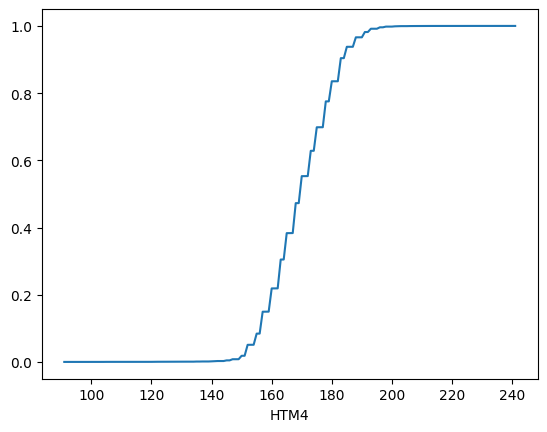

In [11]:
height = brfss['HTM4']
cdf = Cdf.from_seq(height)
cdf.plot()

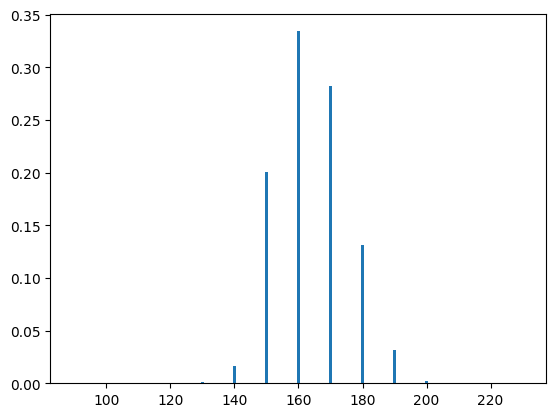

In [12]:
bins = np.arange(0, height.max(), 10)
brfss['_HTM4G10'] = pd.cut(brfss['HTM4'], bins=bins, labels=bins[:-1]).astype(float)

pmf = Pmf.from_seq(brfss['_HTM4G10'])
pmf.bar()

In [13]:
brfss['WTKG3'] /= 100
brfss['WTKG3'].describe()

count    398105.000000
mean         83.157659
std          21.417652
min          22.680000
25%          68.040000
50%          80.740000
75%          95.250000
max         293.020000
Name: WTKG3, dtype: float64

<Axes: xlabel='WTKG3'>

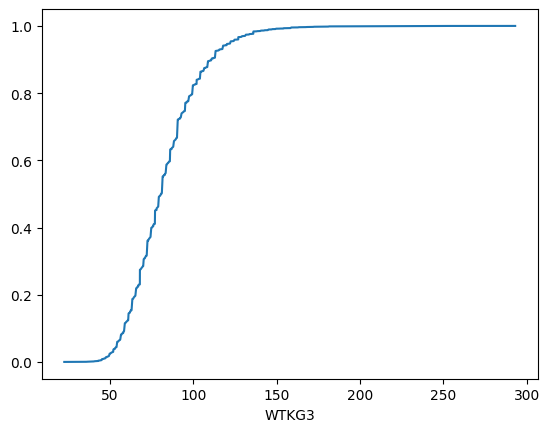

In [14]:
Cdf.from_seq(brfss['WTKG3']).plot()

To map from age groups to ages, I use the following formula, which maps each code to the approximate midpoint of its range.

In [15]:
df = pd.DataFrame(index=range(1,14))
df['AGE'] = df.index * 5 + 17
df

,AGE
1,22
2,27
3,32
4,37
5,42
6,47
7,52
8,57
9,62
10,67


In [16]:
brfss['_AGEG5YR'].replace(14, np.nan, inplace=True)
brfss['AGE'] = brfss['_AGEG5YR'] * 5 + 17

In [17]:
brfss['AGE'].value_counts().sort_index()

AGE
22.0    26025
27.0    21623
32.0    25724
37.0    28559
42.0    29435
47.0    28391
52.0    34086
57.0    38009
62.0    44298
67.0    45762
72.0    42920
77.0    29747
82.0    34507
Name: count, dtype: int64

In [18]:
brfss['_INCOMG1'].replace(9, np.nan, inplace=True)
brfss['_INCOMG1'].value_counts().sort_index()

_INCOMG1
1.0     22408
2.0     36031
3.0     43893
4.0     48339
5.0    107246
6.0     67411
7.0     18952
Name: count, dtype: int64

In [19]:
brfss['_VEGESU1'] /= 100

In [20]:
bogus = (brfss['_VEGESU1'] > 10)
brfss.loc[bogus, '_VEGESU1'] = 10

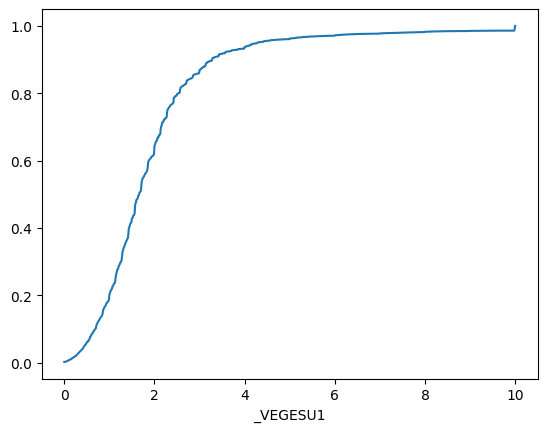

In [21]:
from empiricaldist import Cdf

cdf = Cdf.from_seq(brfss['_VEGESU1'])
cdf.plot();

Sample: I've decided to leave the extract unsampled so we can demonstrate resampling in Chapter 12.

In [22]:
import utils

np.random.seed(17)
sample = utils.resample_rows_weighted(brfss, '_LLCPWT').reset_index(drop=True).drop(columns=['_LLCPWT'])
sample.head()

,SEQNO,HTM4,WTKG3,_SEX,_AGEG5YR,_VEGESU1,_INCOMG1,_HTM4G10,AGE
0,2021003034,160.0,65.77,2,1.0,3.14,5.0,150.0,22.0
1,2021003091,168.0,78.93,1,8.0,NaN,6.0,160.0,57.0
2,2021008029,NaN,58.97,1,NaN,1.00,NaN,NaN,NaN
3,2021005900,168.0,74.84,1,3.0,2.28,7.0,160.0,32.0
4,2021000094,168.0,81.65,2,2.0,1.28,4.0,160.0,27.0


Write the data

In [23]:
out_file = 'brfss_2021.hdf'

In [24]:
!rm brfss_2021.hdf

In [25]:
brfss.to_hdf(out_file, 'brfss', complevel=6)

In [26]:
!ls -lh brfss_2021.hdf

-rw-rw-r-- 1 downey downey 13M Mar 29 13:39 brfss_2021.hdf


In [27]:
!cp brfss_2021.hdf ../data

# add the new file to the repo from the command line

*Elements of Data Science*

Copyright 2021 [Allen B. Downey](https://allendowney.com)

License: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)